# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal de clasificación con **Keras 3**.

En este ejercicio vas a aplicar la misma receta sobre un dataset diferente:

> **Olivetti Faces**

El dataset contiene imágenes de rostros en escala de grises. El objetivo será identificar a cuál persona pertenece cada imagen.

No necesitas diseñar un pipeline de datos nuevo. La carga, división y visualización están resueltas.

Tu trabajo se concentra en completar las etapas principales de Keras:

```text
Datos
  ↓
Modelo
  ↓
Loss + Optimizer
  ↓
Entrenamiento
  ↓
Evaluación
  ↓
Predicción
```

---

## ¿Qué debes completar?

Las celdas marcadas con `# TODO` contienen espacios que debes completar.

El resto del código está preparado para que puedas concentrarte en los conceptos vistos en clase.


---
## 0. Importar librerías

Usaremos:

- **Keras 3** para construir y entrenar la red.
- **scikit-learn** para cargar Olivetti Faces y dividir los datos.
- **NumPy** para manipular arrays.
- **Matplotlib** para visualizar imágenes.


In [1]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: Olivetti Faces

Olivetti Faces contiene:

- **400 imágenes**
- imágenes de **64 × 64 píxeles**
- escala de grises
- **40 personas**
- **10 imágenes por persona**

La etiqueta indica la identidad de la persona:

```text
0, 1, 2, ..., 39
```

Cada imagen ya viene representada con valores flotantes aproximadamente en el rango:

$$
[0,1]
$$

Por eso, en este ejercicio **no necesitamos normalizar dividiendo por 255**.


In [2]:
# Esta parte está resuelta.

faces = fetch_olivetti_faces(
    shuffle=True,
    random_state=SEED
)

X = faces.images
y = faces.target

print("X:", X.shape)
print("y:", y.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Número de clases:", len(np.unique(y)))


X: (400, 64, 64)
y: (400,)
Valor mínimo: 0.0
Valor máximo: 1.0
Número de clases: 40


## 1.1 Dividir entrenamiento y prueba

Como solo tenemos 10 imágenes por persona, debemos asegurarnos de que todas las identidades aparezcan tanto en entrenamiento como en prueba.

Usaremos una división **estratificada**:

```text
80% entrenamiento
20% prueba
```

La opción:

```python
stratify=y
```

mantiene la proporción de cada clase en ambos conjuntos.

Esta parte está resuelta.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nPersonas en train:", len(np.unique(y_train)))
print("Personas en test :", len(np.unique(y_test)))


X_train: (320, 64, 64)
X_test : (80, 64, 64)
y_train: (320,)
y_test : (80,)

Personas en train: 40
Personas en test : 40


### Pregunta 1

Cada imagen tiene tamaño:

$$
64 \times 64
$$

Cuando apliquemos `Flatten()`, ¿cuántos valores tendrá cada ejemplo?

**Respuesta:** 64 x 64 = **4096** valores por imagen.

---
## 1.2 Visualizar algunas imágenes

Esta parte está resuelta.

Observa que varias fotografías corresponden a la misma persona con pequeñas variaciones de expresión, iluminación y orientación.


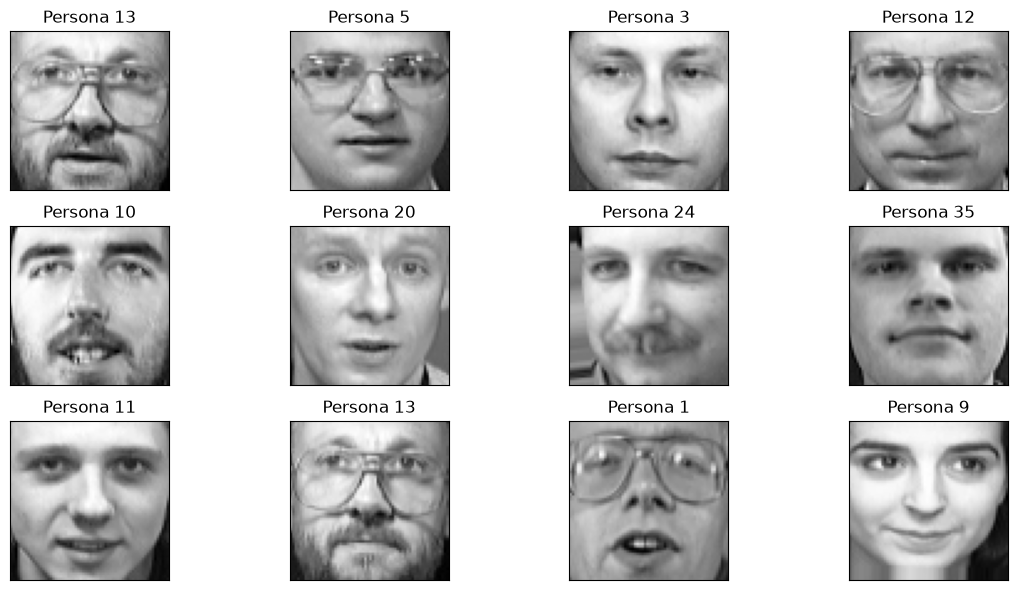

In [4]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Persona {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Usaremos una arquitectura fully-connected similar a la vista en clase:

```text
Imagen 64×64
     ↓
Flatten
     ↓
4096 valores
     ↓
Dense(64)
     ↓
ReLU
     ↓
Dense(40)
     ↓
Logits
```

La última capa debe tener una salida por cada clase.

> **Importante:** no añadas `Softmax` al final. Trabajaremos directamente con **logits**.


In [5]:
# TODO 1 — Completar la arquitectura.

model = keras.Sequential([

    keras.Input(shape=(64, 64)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(40)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,808 (1.01 MB)

 Trainable params: 264,808 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Validación TODO 1

assert isinstance(model, keras.Model)

# Dense(64): 4096*64 + 64
# Dense(40): 64*40 + 40
expected_params = (4096 * 64 + 64) + (64 * 40 + 40)

assert model.count_params() == expected_params, (
    f"Se esperaban {expected_params:,} parámetros, "
    f"pero el modelo tiene {model.count_params():,}."
)

print("✓ Arquitectura correcta.")
print(f"Parámetros entrenables: {model.count_params():,}")


✓ Arquitectura correcta.
Parámetros entrenables: 264,808


### Pregunta 2

¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Porque la capa `Dense` recibe un vector, no una matriz. Cada neurona hace una suma ponderada de todas sus entradas, entonces la imagen de 64x64 hay que convertirla en un vector de 4096 números para que cada píxel tenga su peso.

### Pregunta 3

¿Por qué la última capa tiene **40 neuronas**?

**Respuesta:** Porque hay 40 personas distintas y necesitamos un logit por cada clase. La neurona con el logit más grande es la persona que predice el modelo.

### Pregunta 4

¿Qué función cumple `ReLU` en la capa oculta?

**Respuesta:** ReLU deja pasar los valores positivos y convierte los negativos en 0. Eso le da no linealidad a la red; sin ella las dos capas Dense serían equivalentes a una sola transformación lineal y la red no podría aprender relaciones más complejas. En este ejercicio también vimos el lado malo de ReLU: si la entrada de una neurona es negativa para todos los ejemplos, la neurona se muere y deja de aprender.

---
# 3. Configurar el entrenamiento

Las etiquetas son números enteros entre:

```text
0 y 39
```

Por eso usaremos:

```python
SparseCategoricalCrossentropy
```

Además:

- el modelo produce **logits**,
- usaremos **Adam**,
- mediremos **accuracy**.

Completa `model.compile()`.


In [7]:
lr_rate = 0.001

# TODO 2 — Configurar loss, optimizer y métrica.

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=lr_rate
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)

print("✓ Modelo configurado.")

✓ Modelo configurado.


### Pregunta 5

¿Por qué usamos:

```python
from_logits=True
```

en la función de pérdida?

**Respuesta:** Porque la última capa no tiene softmax y devuelve logits, que pueden ser cualquier número. Con `from_logits=True` la función de pérdida aplica softmax por dentro antes de calcular la cross entropy, y lo hace de una forma numéricamente más estable. Si lo dejáramos en False, Keras trataría los logits como si ya fueran probabilidades y la loss quedaría mal calculada.

---
# 4. Entrenar el modelo

Usaremos:

```python
epochs = 30
batch_size = 32
```

El dataset es pequeño, por lo que el entrenamiento debería ser rápido.

Keras realizará internamente:

```text
Forward pass
      ↓
Calcular loss
      ↓
Backpropagation
      ↓
Actualizar parámetros con Adam
```

Completa la llamada a `fit()`.


In [8]:
epochs = 30
batch_size = 32

# TODO 3 — Entrenar el modelo.

history = model.fit(

    X_train,
    y_train,

    epochs=epochs,
    batch_size=batch_size,

    validation_data=(X_test, y_test),

    shuffle=True
)

Epoch 1/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 3s 438ms/step - accuracy: 0.0312 - loss: 3.7614

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0156 - loss: 3.9050 - val_accuracy: 0.0250 - val_loss: 3.6889


Epoch 2/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0312 - loss: 3.6883

...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0312 - loss: 3.6885

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0250 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889


Epoch 30/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0312 - loss: 3.6885

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0250 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889


### Pregunta 6

¿Qué representa una **epoch**?

**Respuesta:** Una epoch es una pasada completa por todos los datos de entrenamiento. Con 30 epochs la red vio las 320 imágenes 30 veces.

### Pregunta 7

¿Qué significa `batch_size=32`?

**Respuesta:** Que los datos se dividen en grupos de 32 imágenes y después de cada grupo se calcula la loss, se hace backpropagation y se actualizan los pesos. Con 320 imágenes salen 10 actualizaciones por epoch.

---
## 4.1 Visualizar el entrenamiento

Esta parte está resuelta.

El dataset tiene muy pocos ejemplos comparado con el número de parámetros de la red.

Observa cuidadosamente la diferencia entre entrenamiento y validación.


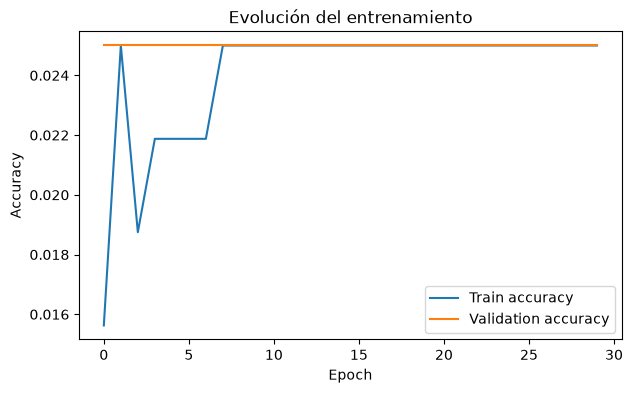

In [9]:
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()

plt.show()


### Pregunta 8

Observando la gráfica:

- ¿El accuracy de entrenamiento sigue aumentando?
- ¿El accuracy de validación se comporta igual?
- ¿Observas evidencia de **overfitting**?

**Respuesta:** En la primera ejecución la gráfica no muestra aprendizaje: la accuracy de train sube un poco al principio y luego queda plana en 0.025, igual que la de validación, que estuvo en 0.025 desde la primera epoch. Esto no es overfitting, es que la red no aprendió nada porque se murieron las neuronas ReLU (lo explico y lo arreglo más abajo).

Con los datos centrados la historia cambia. La accuracy de train sube muy rápido y llega a 1.0 en la epoch 10, y después sigue bajando la loss de train hasta 0.011. La de validación sube hasta 0.95 en la epoch 12 y ahí se queda quieta hasta el final. Sí hay señales de overfitting: train queda en 100 % y validación en 95 %, y la loss de validación (0.26) queda mucho más alta que la de train (0.01). La red se aprende perfecto las 320 fotos pero no generaliza igual de bien. De todas formas la validación no empeora, solo deja de mejorar.

---
# 5. Evaluar el modelo

Ahora evaluaremos el modelo sobre imágenes que no fueron utilizadas para actualizar sus parámetros.

Completa `evaluate()`.


In [10]:
# TODO 4 — Evaluar.

test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,

    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")

Test loss     : 3.6889
Test accuracy : 0.0250
Accuracy (%)  : 2.50%


### Problema: la red se quedó pegada en 2.5 %

Con las 30 épocas la accuracy no subió nunca, ni en train ni en validación, y quedó en **0.025**. Eso es exactamente 1/40, o sea lo mismo que adivinar al azar entre 40 personas. Además la loss quedó fija en 3.689, que es ln(40), el valor que da la cross entropy cuando el modelo le pone la misma probabilidad a todas las clases. Los logits de la imagen de prueba también salieron casi todos en cero y las probabilidades todas cerca de 0.025.

Mi sospecha es que las neuronas ReLU de la capa oculta se murieron. Una neurona ReLU está muerta cuando su entrada es negativa para todos los ejemplos: siempre da 0 y su gradiente también es 0, entonces ya no aprende más. Si las 64 se mueren, la última capa solo recibe ceros y lo único que puede aprender es el bias, por eso predice lo mismo para todas las caras.

Lo reviso calculando a mano la salida de la capa oculta para todo el train:

In [11]:
W, b = model.layers[1].get_weights()
X_flat = X_train.reshape(len(X_train), -1)

hidden = np.maximum(0, X_flat @ W + b)
muertas = np.sum(hidden.max(axis=0) == 0)

print("Neuronas ocultas:", hidden.shape[1])
print("Neuronas muertas (salida 0 para todas las imagenes):", muertas)
print("Loss final de train:", round(history.history["loss"][-1], 4), " ln(40) =", round(np.log(40), 4))
print("Valores de los pixeles: min", X_train.min(), "max", X_train.max(), "promedio", round(X_train.mean(), 3))

Neuronas ocultas: 64
Neuronas muertas (salida 0 para todas las imagenes): 64
Loss final de train: 3.689  ln(40) = 3.6889
Valores de los pixeles: min 0.0 max 1.0 promedio 0.547


Efectivamente las 64 neuronas están muertas.

**¿Por qué pasa esto?** Todos los píxeles están entre 0 y 1, o sea que son positivos, y además las caras se parecen mucho entre sí (fondo oscuro, la cara en el centro). Entonces para cada neurona la suma de pesos por píxeles da casi el mismo signo para todas las imágenes. Las neuronas que empiezan con la suma negativa ya nacen muertas, y en las primeras actualizaciones de Adam los pesos se mueven todos para el mismo lado (porque las entradas son todas positivas) y empujan al resto a la zona negativa. Una vez ahí no pueden volver porque el gradiente de ReLU es 0.

### Arreglo: centrar los datos

Sin cambiar la arquitectura, le resto a cada píxel su promedio calculado **solo con X_train** (para no usar información del test). Así los datos quedan alrededor de 0, con valores positivos y negativos, y cada neurona recibe entradas de los dos signos según la imagen, entonces no se apagan todas al tiempo. Al test le resto el mismo promedio de train.

In [12]:
mean_train = X_train.mean(axis=0)

X_train = X_train - mean_train
X_test = X_test - mean_train

print("Promedio train despues de centrar:", round(float(X_train.mean()), 6))
print("Min y max train:", round(float(X_train.min()), 3), round(float(X_train.max()), 3))

# misma arquitectura de antes
keras.utils.set_random_seed(SEED)

model = keras.Sequential([
    keras.Input(shape=(64, 64)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(40)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

assert model.count_params() == expected_params

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)

Promedio train despues de centrar: 0.0
Min y max train: -0.639 0.634
Epoch 1/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 3s 405ms/step - accuracy: 0.0625 - loss: 3.6489

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1906 - loss: 3.2360 - val_accuracy: 0.3875 - val_loss: 2.6878


Epoch 2/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6250 - loss: 2.2336

...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0096

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 0.9500 - val_loss: 0.2667


Epoch 30/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0090

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0107 - val_accuracy: 0.9500 - val_loss: 0.2648


Neuronas muertas ahora: 0


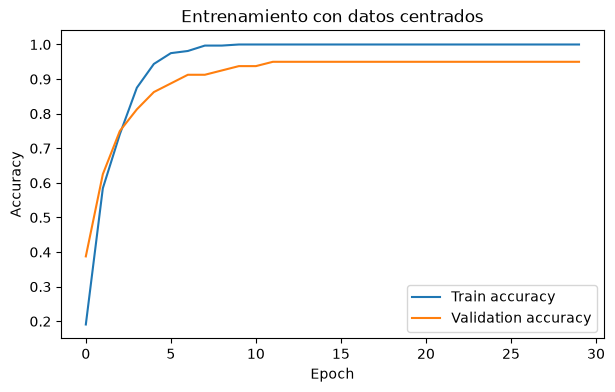

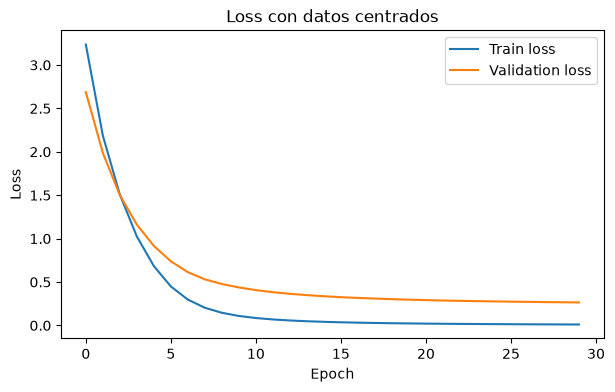

In [13]:
W, b = model.layers[1].get_weights()
hidden = np.maximum(0, X_train.reshape(len(X_train), -1) @ W + b)
print("Neuronas muertas ahora:", np.sum(hidden.max(axis=0) == 0))

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Entrenamiento con datos centrados")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss con datos centrados")
plt.legend()
plt.show()

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")

Test loss     : 0.2648
Test accuracy : 0.9500
Accuracy (%)  : 95.00%


### Pregunta 9

Tenemos **40 clases**, pero solamente **320 imágenes de entrenamiento**.

¿Crees que la cantidad de datos es grande o pequeña para una red con cientos de miles de parámetros?

**Respuesta:** Es una cantidad muy pequeña. La red tiene 264,808 parámetros y solo 320 imágenes, o sea unos 8 ejemplos por persona y más de 800 parámetros por cada imagen. Con tan pocos datos la red puede memorizar el train fácilmente, que fue lo que pasó (100 % en train). Aun así logró 95 % en test, creo que porque las fotos de cada persona son muy parecidas entre sí (mismo fondo, misma posición).

---
# 6. Logits y Softmax

La salida de nuestro modelo tiene forma:

```text
(batch_size, 40)
```

Cada uno de los 40 valores corresponde al **logit** asociado a una persona.

Los logits no son probabilidades.

Para convertirlos en probabilidades usamos:

```python
keras.ops.softmax(...)
```


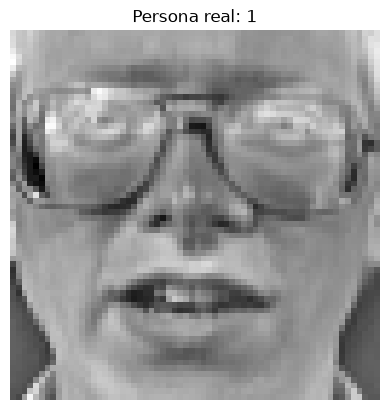

Shape de logits: (1, 40)

Primeros 10 logits:
[ 0.95183855  7.020842   -2.0416768  -0.5775714  -2.6489968  -5.3261623
 -2.1351101  -1.5170492  -5.362593   -4.434405  ]


In [15]:
index = 0

image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Persona real: {true_class}")
plt.axis("off")
plt.show()

# Añadimos dimensión de batch:
# (64,64) -> (1,64,64)
image_batch = np.expand_dims(image, axis=0)

# Forward pass.
logits = model(
    image_batch,
    training=False
)

print("Shape de logits:", logits.shape)
print("\nPrimeros 10 logits:")
print(
    keras.ops.convert_to_numpy(logits)[0, :10]
)


In [16]:
# TODO 5 — Convertir logits a probabilidades.

probabilities = keras.ops.softmax(logits)

# TODO 6 — Obtener la clase con mayor probabilidad.

prediction = keras.ops.argmax(
    probabilities,
    axis=1
)

prediction = int(
    keras.ops.convert_to_numpy(prediction)[0]
)

print()
print("Persona real     :", true_class)
print("Persona predicha :", prediction)


Persona real     : 1
Persona predicha : 1


In [17]:
# Revisamos las cinco clases con mayor probabilidad.

probabilities_np = keras.ops.convert_to_numpy(
    probabilities
)[0]

top5 = np.argsort(
    probabilities_np
)[-5:][::-1]

print("Top 5 predicciones:\n")

for class_id in top5:
    print(
        f"Persona {class_id:2d}: "
        f"{probabilities_np[class_id]:.4f}"
    )

print(
    "\nSuma de probabilidades:",
    probabilities_np.sum()
)


Top 5 predicciones:

Persona  1: 0.9613
Persona 26: 0.0116
Persona 33: 0.0095
Persona 13: 0.0051
Persona 18: 0.0030

Suma de probabilidades: 1.0000001


### Pregunta 10

¿Por qué la suma de las 40 probabilidades obtenidas con `Softmax` debe ser aproximadamente `1`?

**Respuesta:** Porque softmax convierte los logits en una distribución de probabilidad: eleva e a cada logit y divide por la suma de todos. Así todos los valores quedan entre 0 y 1 y la suma da 1. Como el modelo tiene que repartir la probabilidad entre las 40 personas, todas juntas deben sumar 1. En la salida dio 1.0000001, la diferencia es solo por redondeo de punto flotante.

---
# 7. Visualizar varias predicciones

Esta parte está resuelta.

Observa especialmente los casos en los que el modelo se equivoca.


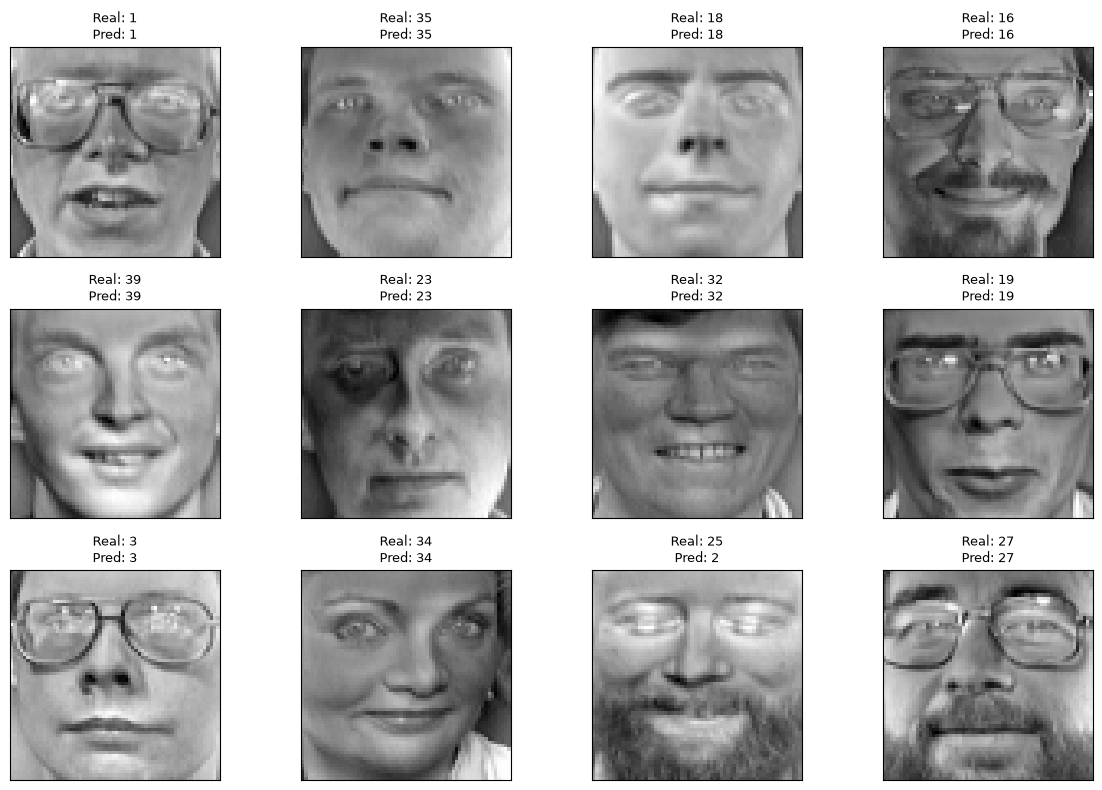

In [18]:
n = 12

logits_batch = model(
    X_test[:n],
    training=False
)

predictions = keras.ops.argmax(
    logits_batch,
    axis=1
)

predictions = keras.ops.convert_to_numpy(
    predictions
)

plt.figure(figsize=(12, 8))

for i in range(n):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    real = y_test[i]
    pred = predictions[i]

    plt.title(
        f"Real: {real}\nPred: {pred}",
        fontsize=9
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 8. Reflexión final

Responde brevemente.

### 1. ¿Cuál fue el accuracy final del modelo?

**Respuesta:** Después del arreglo la accuracy en test fue **0.95 (95 %)**, o sea 76 de las 80 caras bien clasificadas. Sin centrar los datos fue solo 0.025, igual que adivinar.

### 2. ¿Observaste overfitting? ¿Qué evidencia utilizaste?

**Respuesta:** Sí. La evidencia es que la accuracy de train llegó a 1.0 y la loss de train casi a 0, mientras que validación se quedó en 0.95 y su loss en 0.26. Esa diferencia entre las dos curvas es overfitting, aunque moderado porque la validación no empezó a bajar.

### 3. ¿Qué ocurre cuando tenemos muchos parámetros pero pocos ejemplos de entrenamiento?

**Respuesta:** El modelo puede memorizar los ejemplos de entrenamiento en lugar de aprender características generales. Llega a 100 % en train pero se equivoca más con datos nuevos. Con más parámetros que ejemplos hay muchas soluciones que encajan perfecto con el train y no todas sirven para generalizar.

### 4. Después de `Flatten()`, una cara de 64×64 se convierte en un vector de 4096 números.

¿Qué información sobre la estructura de la imagen deja de representar explícitamente esta transformación?

**Respuesta:** Deja de representar qué píxeles son vecinos. Después de Flatten el píxel de arriba y el de abajo quedan a 64 posiciones de distancia en el vector, entonces la red no sabe que forman parte de la misma zona (un ojo, la nariz). Se pierde la idea de bordes, formas y patrones locales; si la cara se mueve un poco, los mismos rasgos caen en otras posiciones del vector y la red los ve como algo totalmente distinto.

### 5. ¿Crees que una arquitectura diseñada específicamente para imágenes podría aprovechar mejor la información espacial?

**Respuesta:** Sí. Una CNN usa filtros pequeños que recorren la imagen y detectan bordes, ojos o bocas sin importar la posición exacta, y comparte los mismos pesos en toda la imagen. Así necesita muchos menos parámetros que una capa Dense con 4096 entradas, lo que también ayudaría con el problema de tener tan pocos datos.

---

## Para pensar

Nuestra red recibe:

```text
64 × 64
   ↓
Flatten
   ↓
4096 números
   ↓
Dense
```

Pero una imagen tiene una estructura espacial:

- píxeles cercanos están relacionados,
- existen bordes,
- existen formas,
- existen patrones locales.

Una red fully-connected no incorpora explícitamente esa estructura.

Esto motiva una arquitectura diseñada específicamente para imágenes:

> **Convolutional Neural Networks (CNNs)**

---
# Resumen

En este ejercicio aplicaste nuevamente la receta básica de entrenamiento de una red neuronal:

```text
Dataset
   ↓
Train / Test split
   ↓
Sequential
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense(40)
   ↓
Cross-Entropy
   ↓
Adam
   ↓
fit()
   ↓
evaluate()
```

Los componentes de Keras son los mismos que usamos en clase.

Lo que cambió fue:

- el dataset,
- el tamaño de las imágenes,
- el número de clases,
- y la dificultad del problema.
